# What Contributes to a Movie's Success?
##### By Yogi patel
##### ID: 100920189

## Introduction

A movie's success can be determined by its box office gross and critical acclaim. The "Ultimate 1Million Movies Dataset", sourced from Kaggle, provides millions of movies within its dataset with a variety of variables such as the IMDb rating, date of release, budget, revenue, genres, langues, country of origin, keywords, and much more. 

For the scope of this assignment, I will filter the movies by a specific number of votes to reduce its dataset size and focus on the variables that will be most relevant in answering questions about what contributes to a movie's success. 
Here are some questions I want to explore: 

1. Does a bigger budget result in a higher revenue or rating? 
2. Do year of release and genre contribute to a movie's success? 
3. Does a movie's success rate depend on the reputation of the director and country of origin? 

## Data Processing and Cleaning
I will be loading and processing the data by removing irrelevant variables, handle missing data, and improve the overall presentation.

In [220]:
import csv
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Note: I've reduced the orignal file size of ~900mb by getting rid of irrelevant colums and rows and keeping only the movies with 10k IMDb votes or higher.

In [221]:
# Importing the dataset and storing it in "movie_data" variable
movie_data = pd.read_csv("reduced_TMDB_all_movies.csv")

In [222]:
# Removing the rows where status is anything other than "Relesed" 
movie_data = movie_data[movie_data["status"] == "Released"]

In [223]:
# Dropping unwanted columns
movie_data = movie_data.drop(columns=["status", "Unnamed: 0"])

In [224]:
# Dropping all the rows with missing variables
movie_data = movie_data.dropna(axis=0)

In [225]:
# Sorting the rows in descending oder of IMDb ratings for presentation
movie_data = movie_data.sort_values(by="imdb_rating", ascending=False)

In [226]:
# Removing movies with revenue and budget of 0
movie_data = movie_data[(movie_data["revenue"] > 0) & (movie_data["budget"] > 0)]

In [227]:
# Resetting to index to ensure it only counts the current rows after filtering
movie_data = movie_data.reset_index(drop=True)
movie_data.tail()

,title,release_date,revenue,budget,genres,production_countries,director,imdb_rating,imdb_votes
7064,Justin Bieber's Believe,2013-12-19,3.2e+07,5.0e+06,"Documentary, Music",United States of America,Jon M. Chu,1.6,17938.0
7065,The Cost of Deception,2021-10-21,2.0e+05,2.5e+06,"Crime, Drama",Hungary,Keith English,1.5,40625.0
7066,Dream.net,2009-04-16,1.7e+05,3.5e+06,Comedy,Hungary,Gábor Forgács,1.3,10024.0
7067,Foodfight!,2012-06-15,7.4e+04,6.5e+07,"Adventure, Comedy, Action, Animation, Family",United States of America,Lawrence Kasanoff,1.3,12131.0
7068,Saving Christmas,2014-11-14,2.8e+06,5.0e+05,"Comedy, Fantasy",United States of America,Darren Doane,1.3,16873.0


In [228]:
# Scaling revenue and budget to a million and votes to 1000 for readability
movie_data[["revenue", "budget"]] = movie_data[["revenue", "budget"]] / 1000000
movie_data["imdb_votes"] = movie_data["imdb_votes"] / 1000

In [229]:
# Updating release date to only include the year of release and converting it to integer
movie_data["release_date"] = movie_data["release_date"].str[:4].astype(int)

In [230]:
# Updating the column names 
movie_data.columns = ["Title", "Year", "Revenue (M)", "Budget (M)", "Genres", "Country", "Director", "Rating", "Votes (K)"]

In [231]:
# Setting display precision for numeric values to 1 decimal place
pd.set_option("display.precision", 1)
movie_data.head()

,Title,Year,Revenue (M),Budget (M),Genres,Country,Director,Rating,Votes (K)
0,The Shawshank Redemption,1994,28.3,25.0,"Drama, Crime",United States of America,Frank Darabont,9.3,2961.8
1,The Godfather,1972,245.1,6.0,"Drama, Crime",United States of America,Francis Ford Coppola,9.2,2065.0
2,Batman: Arkham Asylum,2009,36.6,10.0,"Action, Adventure",United States of America,Sefton Hill,9.1,32.5
3,The Godfather Part II,1974,102.6,13.0,"Drama, Crime",United States of America,Francis Ford Coppola,9.0,1394.5
4,Schindler's List,1993,321.4,22.0,"Drama, History, War",United States of America,Steven Spielberg,9.0,1485.2


In [232]:
# Checking the count of values to ensure consistency throughout the data
movie_data.count()

Title          7069
Year           7069
Revenue (M)    7069
Budget (M)     7069
Genres         7069
Country        7069
Director       7069
Rating         7069
Votes (K)      7069
dtype: int64

## Exploratory Data Analysis
Now that we have cleaned the data, we can move on to exploring the trends and relationships between the variables. I will list my observations and deductions at the end of each question section.

### Does bigger budget result in a higher revenue or rating?
I want to explore whether there's a correlation between budget and rating or budget and revenue.

Text(0.5, 1.0, 'Fig 1. Distribution of Budget')

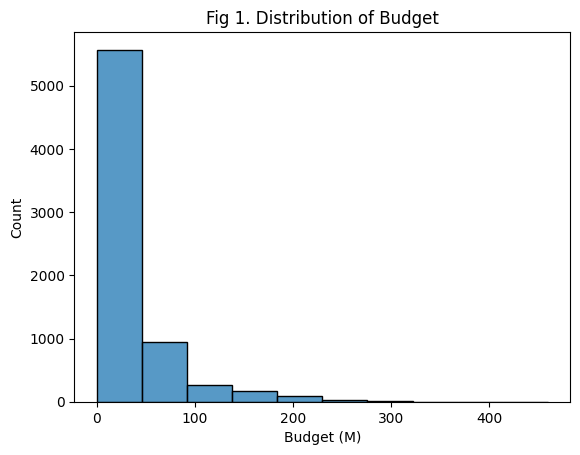

In [233]:
sns.histplot(movie_data["Budget (M)"], bins=10).set_title("Fig 1. Distribution of Budget")

Text(0.5, 1.0, 'Fig 2. Distribution of Rating')

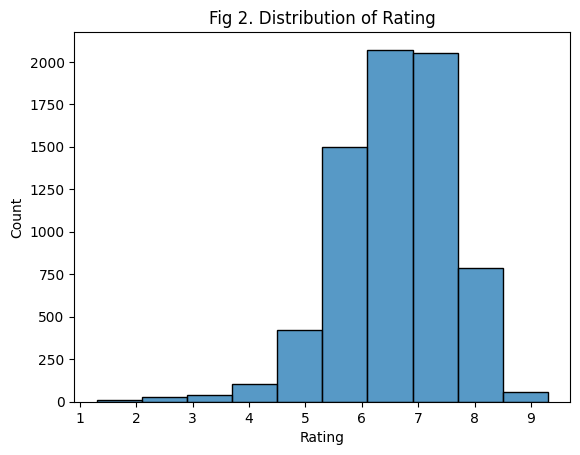

In [234]:
sns.histplot(movie_data["Rating"], bins=10).set_title("Fig 2. Distribution of Rating")

Text(0.5, 1.0, 'Fig 3. Distribution of Revenue')

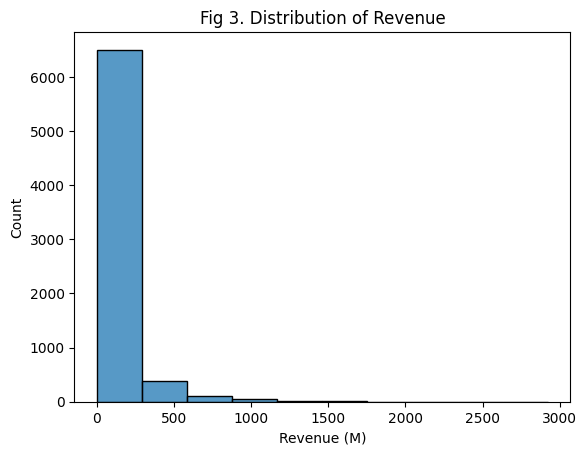

In [235]:
sns.histplot(movie_data["Revenue (M)"], bins=10).set_title("Fig 3. Distribution of Revenue")

Fig 2 shows that the majority of movies have a rating between 6 to 8, following a bell curve. 

Fig 1 and Fig 3 both show that majority of movies budgets and revenues lie under $100M, showing that relatively few movies are backed by large budgets in the film industry. 

Text(0.5, 1.0, 'Plot 1. Budget vs Rating')

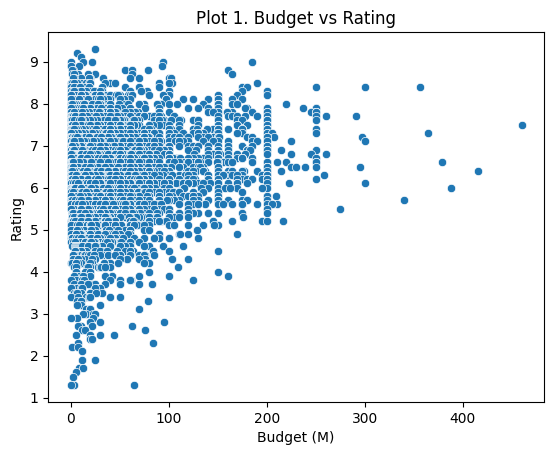

In [236]:
sns.scatterplot(data=movie_data, x="Budget (M)", y="Rating").set_title("Plot 1. Budget vs Rating")

Text(0.5, 1.0, 'Plot 2. Budget vs Revenue')

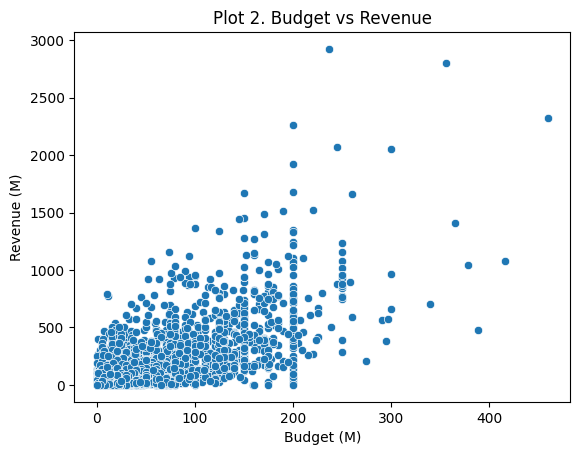

In [237]:
sns.scatterplot(data=movie_data, x="Budget (M)", y="Revenue (M)").set_title("Plot 2. Budget vs Revenue")

Text(0.5, 1.0, 'Plot 3')

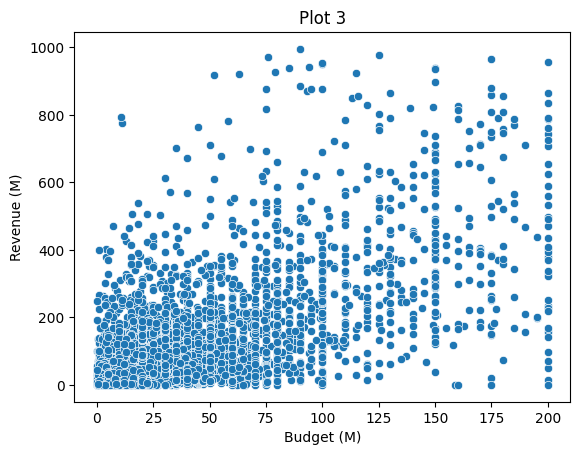

In [238]:
# Created a "movie_data_filtered" variable to only include movies with budget of $200M or lower and revenue of $1000 or lower
# This will zoom into the more clustered area of Plot 2
movie_data_filtered = movie_data[(movie_data["Budget (M)"] <= 200) & (movie_data["Revenue (M)"] <= 1000)]
sns.scatterplot(data=movie_data_filtered, x="Budget (M)", y="Revenue (M)").set_title("Plot 3")

Plot 1 shows that there isn't a strong relationship between budget and rating. It could seem that lower budget films tend to have much lower or much higher rating, this could be because there are significantly higher number of lower budget films over all as seen in Fig 1, which skews the distribution. Therefore, a movie's budget does not play a significant role in determining the movie's rating. 

Plot 2 shows a weak positive correlation between revenue and budget. This could be because higher budget allows for more vfx, big actors, generating higher anticipation, which can result in higher revenue. However, there's a quite a large spread in data with budgets below $200M, as seen in plot 3, suggesting that a higher budget does not always garuntee a higher revenue as you can see that many movies with much lower budget have made significant profit. 

### Do year of release and genre contribute to a movie's success?
Comparing what genres are prominent and how they have changed over time.

In [239]:
# Splitting the genres to handle multiple genres per movie
# Creating a copy
split_genres = movie_data 
# Splitting the data
split_genres["Genres"] = split_genres["Genres"].str.split(", ") 
# Exploding the data 
split_genres = split_genres.explode("Genres") 

In [240]:
# Printing the counts of movies in each genre
split_genres.groupby("Genres")["Title"].count().sort_values(ascending=False)

Genres
Drama              3276
Comedy             2499
Thriller           1918
Action             1809
Romance            1286
Adventure          1276
Crime              1186
Horror              934
Science Fiction     830
Fantasy             729
Family              706
Mystery             652
History             395
Animation           384
War                 268
Music               225
Western             123
Documentary          52
TV Movie              6
Name: Title, dtype: int64

In [241]:
# Printing the counts of successful movies (rating 7.5 or over OR revenue of $100 or over) in each genre
split_genres[(split_genres["Rating"] >= 7.5) | (split_genres["Revenue (M)"] >= 100)].groupby("Genres")["Title"].count().sort_values(ascending=False)

Genres
Drama              1193
Comedy              873
Action              803
Adventure           704
Thriller            612
Romance             441
Crime               403
Family              393
Science Fiction     377
Fantasy             359
Animation           269
Mystery             204
Horror              194
History             180
War                 135
Music                83
Western              47
Documentary          28
TV Movie              1
Name: Title, dtype: int64

In [242]:
# Successful movies grouped by genre and year
successful_movie_genres = split_genres[(split_genres["Rating"] >= 7.5) | (split_genres["Revenue (M)"] >= 100)].groupby(["Year", "Genres"]).size().sort_values(ascending=False).unstack()

Text(0, 0.5, 'Number of movies')

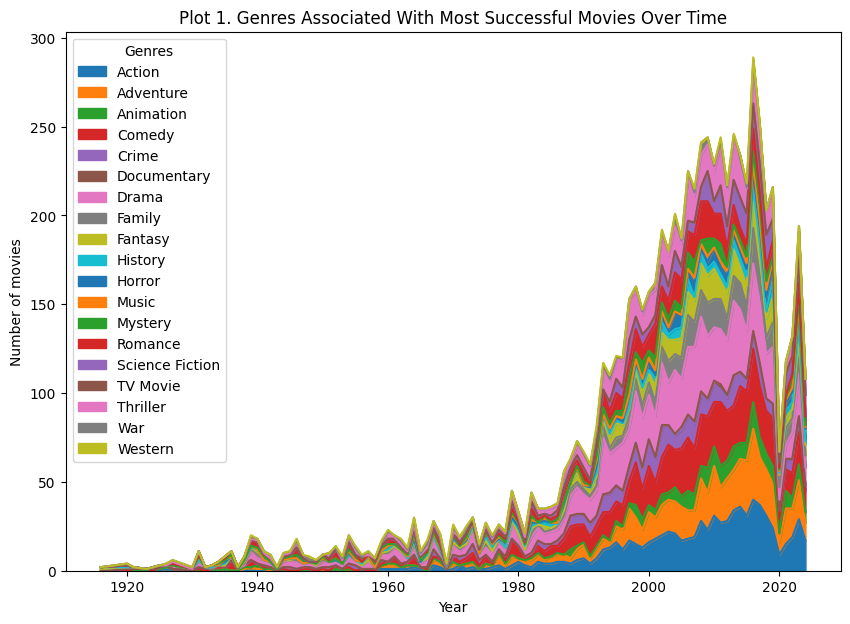

In [243]:
successful_movie_genres.plot(kind="area",figsize=(10,7))
plt.title('Plot 1. Genres Associated With Most Successful Movies Over Time')
plt.ylabel("Number of movies")


In [244]:
# Genres grouped by their average revenenue 
revenue_per_genre = split_genres.groupby("Genres")["Revenue (M)"].mean()

Text(0, 0.5, 'Average Revenue')

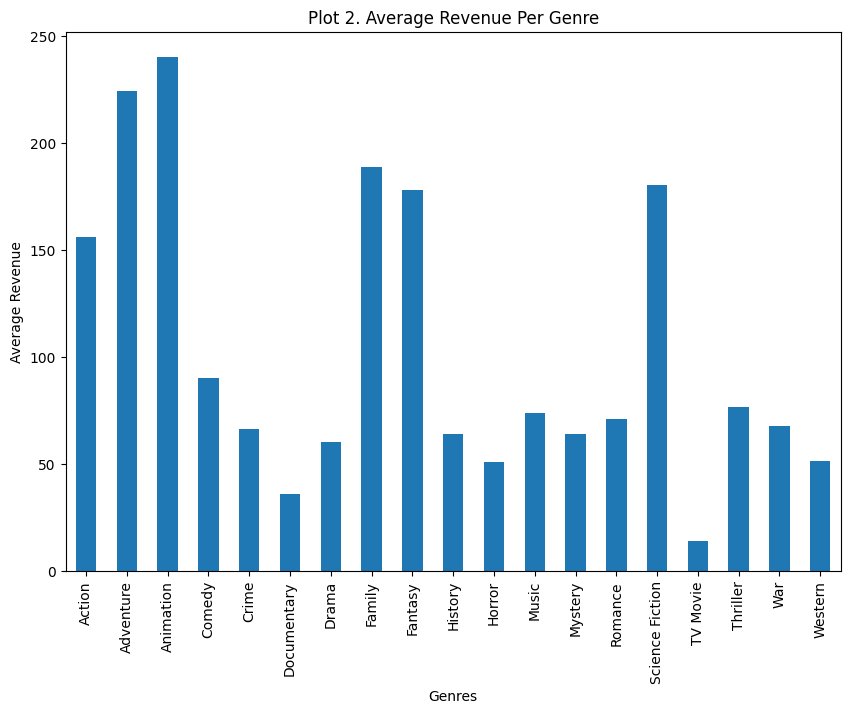

In [245]:
revenue_per_genre.plot(kind="bar", figsize=(10, 7))
plt.title("Plot 2. Average Revenue Per Genre")
plt.ylabel("Average Revenue")

In [246]:
# Genres grouped by their average rating
rating_per_genre = split_genres.groupby("Genres")["Rating"].mean()

Text(0, 0.5, 'Average Rating')

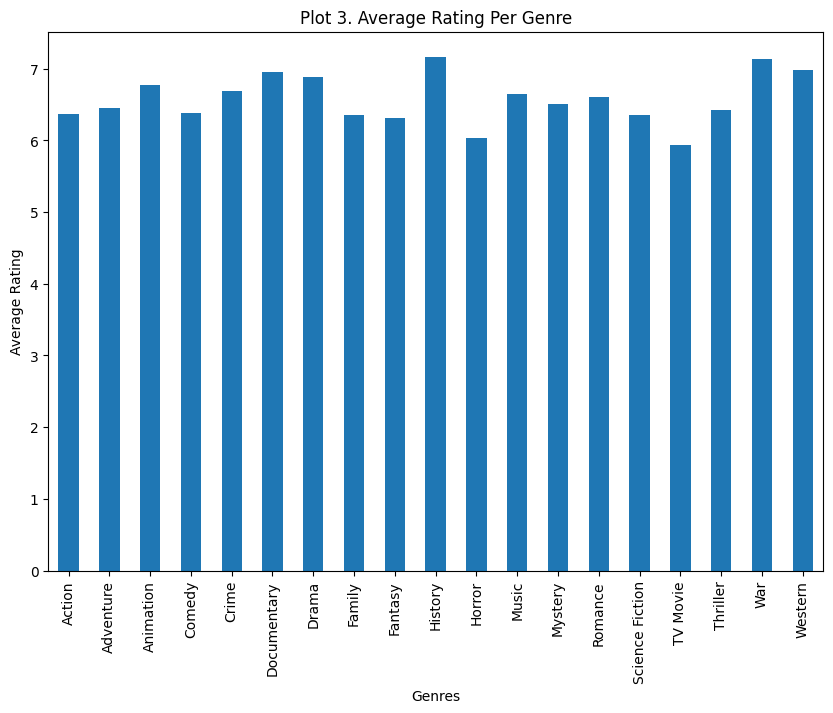

In [247]:
rating_per_genre.plot(kind="bar", figsize=(10, 7))
plt.title("Plot 3. Average Rating Per Genre")
plt.ylabel("Average Rating")

Plot 1 shows that most prominet genres associated with some of the most succesful movies (rated 7.5 or higher or grossing over $100M) include Action, Adventure, Drama, and Comedy. The plot also shows a sharp increase in the number of movies after the 1990s. This could be because of recency bias since IMDb was established in the 1990s and many people who voted for these movies would be from then and onward. As for 1990s and beyond, the genres that seem prominet are some of more accessible genres and also allow for critically acclaimed movies. However, this could be due to the fact that these genres also make for vast majority of movies produced, which can skew the data. Nevertheless, the reason could be because these genres, as I mentioned earlier are accessible and have potential for critical acclaim. 

Plot 2 shows that genres like Action, Animation, Adventure, Family, Fantasy and Sci-Fi dominate in terms of revenue. These are the genres that often associated with big budget films and have a mass appeal. From my personal experience, you're most likely come across posters of movies from these genres when you go to a theatre. These genres are often meant to be seen in theatres for the best experience, and often overlap with one another, resulting in their box office success.

Plot 3 shows that while it seems that there isn't a huge correlation between the movie's genre and it's rating, some genres such as, War, History, Drama, Crime and Animation tend to have slightly higher average ratings. These genres often involve deeper themes, or showcase high artistic value, which can leave a greater emotional impact on audience and result in higher ratings. Overall, this plot suggests that there's potential to produce a highly-rated movie in any genre.

### Does a movie's success rate depend on the reputation of the director and country of origin?
Whether the name and place play a role in critical acclaim or success

In [248]:
# Checking the top 20 directors with most movies rated 7.5 or over in the data set
# These are some of the directors known for having critically acclaimed films
movie_data[movie_data["Rating"] >= 7.5].groupby("Director").size().sort_values(ascending=False).head(10)

Director
Steven Spielberg     16
Martin Scorsese      15
Alfred Hitchcock     12
Stanley Kubrick      10
Hayao Miyazaki       10
Clint Eastwood       10
Billy Wilder          9
Christopher Nolan     9
Quentin Tarantino     9
David Fincher         8
dtype: int64

In [249]:
# Checking the top 20 directors sorted by their average rating
movie_data.groupby(["Director"])["Rating"].mean().sort_values(ascending=False).head(10)

Director
Sefton Hill                                            9.1
Amitabh Reza Chowdhury                                 8.9
Kartal Tibet                                           8.9
Vidhu Vinod Chopra                                     8.8
R. Madhavan                                            8.7
Roberto Benigni                                        8.6
Justin K. Thompson, Kemp Powers, Joaquim Dos Santos    8.6
Roger Allers, Rob Minkoff                              8.5
Tony Kaye                                              8.5
Rodney Rothman, Peter Ramsey, Bob Persichetti          8.4
Name: Rating, dtype: float64

In [250]:
# Checking the countries with most movies rated 7.5 or higher
movie_data[movie_data["Revenue (M)"] >= 7.5].groupby("Country").size().sort_values(ascending=False).head(10)

Country
United States of America                    3312
United Kingdom, United States of America     323
India                                        183
Germany, United States of America            114
Canada, United States of America             111
United Kingdom                                85
France                                        58
France, United States of America              50
Australia, United States of America           43
Japan                                         41
dtype: int64

In [260]:
# Grouping director and country
movie_data[movie_data["Rating"] >= 7.5].groupby(["Director", "Country"]).size().sort_values(ascending=False).head(20)

Director              Country                                 
Steven Spielberg      United States of America                    13
Alfred Hitchcock      United States of America                    12
Hayao Miyazaki        Japan                                       10
Martin Scorsese       United States of America                     9
Billy Wilder          United States of America                     9
Clint Eastwood        United States of America                     8
William Wyler         United States of America                     8
Christopher Nolan     United Kingdom, United States of America     8
Rob Reiner            United States of America                     7
Quentin Tarantino     United States of America                     7
David Fincher         United States of America                     6
John Ford             United States of America                     6
Stanley Kubrick       United Kingdom, United States of America     6
Howard Hawks          United States of A

In [252]:
print("Number of movies with rating of 7.5 and higher:", movie_data[movie_data["Rating"] >= 7.5].shape[0])
print("Number of directors with movies rated 7.5 or higher:", movie_data[movie_data["Rating"] >= 7.5].groupby("Director").size().shape[0])

Number of movies with rating of 7.5 and higher: 1274
Number of directors with movies rated 7.5 or higher: 739


In [253]:
# Checking for directors with most movies grossing $100M or higher in revenue
movie_data[movie_data["Revenue (M)"] >= 100].groupby("Director").size().sort_values(ascending=False).head(20)

Director
Steven Spielberg      26
Ridley Scott          15
Robert Zemeckis       14
Clint Eastwood        14
Tim Burton            13
Ron Howard            12
Michael Bay           11
Christopher Nolan     10
Roland Emmerich       10
Tony Scott            10
Shawn Levy            10
Chris Columbus         9
Martin Scorsese        9
Jon Turteltaub         9
M. Night Shyamalan     9
David Fincher          9
David Yates            8
Gore Verbinski         8
Todd Phillips          8
Francis Lawrence       8
dtype: int64

In [254]:
# Checking the countries with most movies grossing $100M in revenue
movie_data[movie_data["Revenue (M)"] >= 100].groupby("Country").size().sort_values(ascending=False).head(10)

Country
United States of America                    1154
United Kingdom, United States of America     130
Germany, United States of America             42
Canada, United States of America              31
Australia, United States of America           18
Japan, United States of America               15
China, United States of America               14
United Kingdom                                14
India                                         12
France, United States of America              11
dtype: int64

In [255]:
# Grouping director and country
movie_data[movie_data["Revenue (M)"] >= 100].groupby(["Director", "Country"]).size().sort_values(ascending=False).head(20)

Director            Country                                 
Steven Spielberg    United States of America                    18
Robert Zemeckis     United States of America                    13
Michael Bay         United States of America                    11
Clint Eastwood      United States of America                    11
Ron Howard          United States of America                    10
Christopher Nolan   United Kingdom, United States of America     9
Ridley Scott        United States of America                     9
Jon Turteltaub      United States of America                     8
M. Night Shyamalan  United States of America                     8
James Wan           United States of America                     7
Ivan Reitman        United States of America                     7
Gore Verbinski      United States of America                     7
David Fincher       United States of America                     7
Todd Phillips       United States of America                     7
D

In [258]:
print("Number of movies grossing $100M or higher:", movie_data[movie_data["Budget (M)"] >= 100].shape[0])
print("Number of directors with movies grossing $100M or higher:", movie_data[movie_data["Budget (M)"] >= 100].groupby("Director").size().shape[0])

Number of movies grossing $100M or higher: 532
Number of directors with movies grossing $100M or higher: 290


In [256]:
movie_data[movie_data["Revenue (M)"] >= 100].groupby("Director").size().describe()

count    790.0
mean       2.2
std        2.2
min        1.0
25%        1.0
50%        1.0
75%        3.0
max       26.0
dtype: float64

In [257]:
movie_data[movie_data["Rating"] >= 7.5].groupby("Director").size().describe()

count    739.0
mean       1.7
std        1.6
min        1.0
25%        1.0
50%        1.0
75%        2.0
max       16.0
dtype: float64

What I've observed is that if you're an already established director, like Steven Speilberg, Stanley Kubrick, Quentin Tarantino, Christopher Nolan and others that featured prominently on the lists, then you have a higher success rate in terms of revenue and rating. This is evident from the fact that the number of movies with a rating of 7.5 or higher far exceeds the number of directors with the most movies in this range. The same holds true for revenue. However, this is not the only determinant of success, as there are fairly lesser-known directors who have achieved similar results. Descriptive statistcs reveal that around 50% of the directors have only 1 movie rated 7.5 or higher or grossing $100M or more, and 75% have only 1-3 such movies. 

Country-wise, USA dominates in terms of both revenue and ratings. This suggests that Hollywood movies have a wide appeal. Many other English-speaking countries also feature at the top, alongside countries such as India, Germany, France, Japan and so on. Hollywood movie with an American director is more likely to achieve massive sucess at the box office and receive critical acclaim.

## Discussion

In this assignment, I explored what contributes to a movie's success, measured by it's rating and revenue, by looking at budget, genre, director reputation, and country of origin. A bigger budget can sometime lead to a higher revenue but doesn’t always guarantee good ratings. Certain genres, like Action, Adventure, Sci-Fi, and Fantasy, perform well at the box office, while genres like Drama and Animation tend to receive higher ratings, but overall distribution of average ratings acrosss genres is quite balanced. Movies directed by established directors, such as Steven Spielberg, Quentin Tarantino and Christopher Nolan, usually have a higher success rate, but there are many directors whom have had similar success with just one movie. Finally, we saw that USA dominate both ratings and revenue, which suggests that a country can have a major influence in a movie's success, at least on the global scale where Westerm media has a significant influence. 

## References

1. Source data - https://www.kaggle.com/datasets/alanvourch/tmdb-movies-daily-updates
2. Split and explode code, https://www.geeksforgeeks.org/how-to-split-explode-pandas-dataframe-string-entry-to-separate-rows/ 
3. Pandas for data manipulation
4. Seaborn for data viz
5. Matplotlib for data viz 